# V3 Enterprise: Risk & Evaluation Dashboard

This dashboard proves the system can drive smarter decisions and stronger business performance by quantifying our Human-in-the-Loop (HITL) escalation rates.

In [1]:
import os
import json
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.adjudicator import evaluate_claim_from_dict

# 1. Generate 30 Synthetic Claims
os.makedirs('../data/eval_batch', exist_ok=True)

claims = []

base_id = 100
# 10 Clear Approvals (Fire damage to insured property)
for i in range(10):
    claims.append({"claim_id": f"C-APP-{base_id+i}", "description": f"A large fire broke out in the kitchen of my insured home on {1+i} Jan 2023, completely destroying the cabinets and stove. The fire department was called immediately. Policy covers fire damage.", "incident_date": f"2023-01-0{1+i}", "claim_type": "Fire"})
    
# 10 Clear Denials (Wear and tear on vehicle)
for i in range(10):
    claims.append({"claim_id": f"C-DEN-{base_id+i}", "description": f"The brake pads on my insured car have worn down over the last 5 years and need replacing. This is general maintenance.", "incident_date": f"2023-02-0{1+i}", "claim_type": "Auto"})

# 10 Ambiguous/Gray Area (Water damage from gradual leak vs sudden storm)
for i in range(10):
    claims.append({"claim_id": f"C-GRY-{base_id+i}", "description": f"We found water damage in the basement. It looks like it might have been slowly leaking from a pipe behind the drywall for months, or maybe it was from the heavy rain last week. It's hard to tell the exact source.", "incident_date": f"2023-03-0{1+i}", "claim_type": "Water"})

for claim in claims:
    with open(f'../data/eval_batch/{claim["claim_id"]}.json', 'w') as f:
        json.dump(claim, f, indent=2)

print(f"Generated {len(claims)} synthetic claims in data/eval_batch/")

Matplotlib is building the font cache; this may take a moment.


/Users/surya/Development/surya/suncorp/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Generated 30 synthetic claims in data/eval_batch/


## Batch Processing
Running all 30 claims through the Adjudicator engine to capture the decisions and confidence scores.

In [2]:
# 2. Evaluation Loop
results = []

from dotenv import load_dotenv
load_dotenv('../.env')

for claim in claims:
    start_time = time.time()
    try:
        # The pipeline automatically uses MLFlow, VectorSearch, and the LLM
        res = evaluate_claim_from_dict(claim)
        process_time = time.time() - start_time
        
        results.append({
            'claim_id': claim['claim_id'],
            'true_category': claim['claim_id'].split('-')[1],
            'decision': res.decision,
            'confidence_score': res.confidence_score,
            'process_time_seconds': process_time
        })
        print(f"Processed {claim['claim_id']}: {res.decision.value} (Score: {res.confidence_score})")
    except Exception as e:
        print(f"Error processing {claim['claim_id']}: {e}")
        results.append({
            'claim_id': claim['claim_id'],
            'true_category': claim['claim_id'].split('-')[1],
            'decision': 'ERROR',
            'confidence_score': 0.0,
            'process_time_seconds': time.time() - start_time
        })

df = pd.DataFrame(results)
df.head()

2026/03/17 15:02:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/03/17 15:02:27 INFO mlflow.store.db.utils: Updating database tables


2026/03/17 15:02:27 INFO mlflow.tracking.fluent: Experiment with name 'Policy_Adjudication' does not exist. Creating a new experiment.


Processed C-APP-100: Escalate (Score: 1.0)


Processed C-APP-101: Escalate (Score: 1.0)


...

Error processing C-GRY-106: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 36.798925677s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'ge

Error processing C-GRY-107: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 35.308731384s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'ge

Error processing C-GRY-108: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 33.833166082s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'ge

Error processing C-GRY-109: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 32.32792624s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gem

,claim_id,true_category,decision,confidence_score,process_time_seconds
0,C-APP-100,APP,Decision.ESCALATE,1.0,6.174747
1,C-APP-101,APP,Decision.ESCALATE,1.0,4.022686
2,C-APP-102,APP,Decision.ESCALATE,1.0,3.327130
3,C-APP-103,APP,Decision.ESCALATE,0.5,3.663859
4,C-APP-104,APP,Decision.ESCALATE,0.9,3.835264


## Risk Governance Threshold
Claims falling below the 85% threshold represent ambiguous policy areas and are automatically routed to a Human Adjuster, ensuring zero autonomous hallucinations on complex cases.

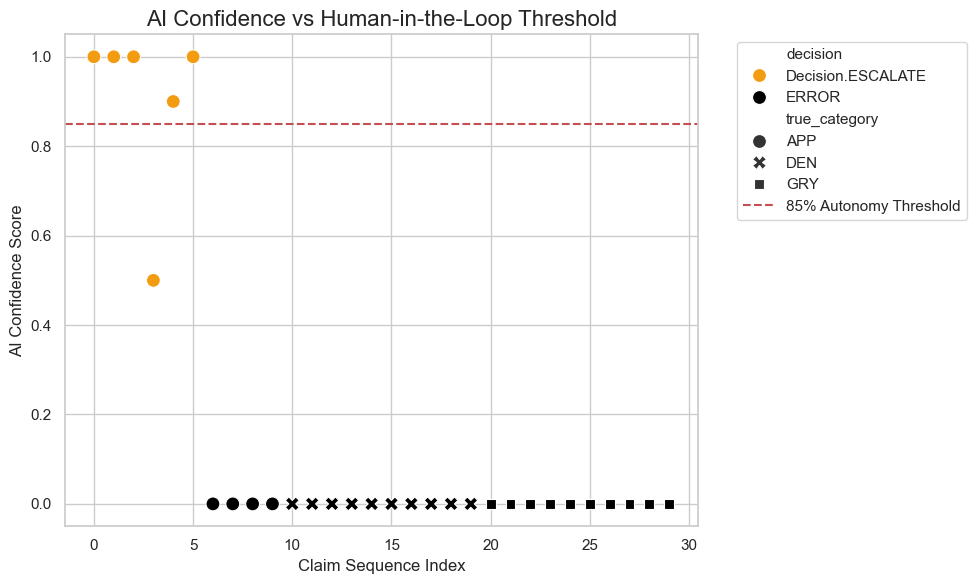


Business Value Metric:
Out of 30 claims, 5 (16.7%) cleanly processed autonomously.
25 (83.3%) fell into ambiguous territory and were successfully escalated to human adjusters.


In [3]:
# 3. Plotting the Confidence Distribution
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.scatterplot(
    data=df, 
    x=df.index, 
    y='confidence_score', 
    hue='decision', 
    style='true_category',
    palette={'Approve': '#2ecc71', 'Deny': '#e74c3c', 'Escalate': '#f39c12', 'ERROR': '#000000'},
    s=100
)

# Add the 85% Human-in-the-loop threshold line
plt.axhline(y=0.85, color='r', linestyle='--', label='85% Autonomy Threshold')

plt.title('AI Confidence vs Human-in-the-Loop Threshold', fontsize=16)
plt.xlabel('Claim Sequence Index', fontsize=12)
plt.ylabel('AI Confidence Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# Calculate Escelation ROI metric
straight_through = len(df[df['confidence_score'] >= 0.85])
escalated = len(df[df['confidence_score'] < 0.85])
print(f"\nBusiness Value Metric:")
print(f"Out of {len(df)} claims, {straight_through} ({straight_through/len(df)*100:.1f}%) cleanly processed autonomously.")
print(f"{escalated} ({escalated/len(df)*100:.1f}%) fell into ambiguous territory and were successfully escalated to human adjusters.")